<a href="https://colab.research.google.com/github/tevatech/logguard/blob/main/mini_siem_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/advanced_logs_dataset.csv')

In [58]:
df.head(10)

,ip,timestamp,status,user_id,attack_type,country,city,log_type,hour,is_night,is_fail
0,192.168.1.29,2026-04-04 20:33:00,SUCCESS,user_7,normal,USA,Berlin,network,20,0,0
1,192.168.1.25,2026-04-04 00:15:00,FAIL,user_23,scan,Russia,Rio de Janeiro,system,0,1,1
2,192.168.1.59,2026-04-01 12:28:00,SUCCESS,user_29,normal,USA,Rio de Janeiro,network,12,0,0
3,192.168.1.45,2026-04-02 03:49:00,FAIL,user_5,scan,Germany,Berlin,system,3,1,1
4,192.168.1.6,2026-04-02 21:15:00,SUCCESS,user_27,normal,India,Moscow,network,21,0,0
5,192.168.1.37,2026-04-05 00:26:00,SUCCESS,user_18,normal,Russia,Rio de Janeiro,network,0,1,0
6,192.168.1.34,2026-04-04 04:33:00,FAIL,user_13,normal,Russia,Berlin,network,4,1,1
7,192.168.1.5,2026-04-04 00:07:00,FAIL,user_9,normal,Russia,Moscow,network,0,1,1
8,192.168.1.25,2026-04-02 02:10:00,FAIL,user_27,brute_force,Germany,Mumbai,system,2,1,1
9,192.168.1.18,2026-04-02 06:22:00,FAIL,user_7,normal,USA,Moscow,auth,6,0,1


# Limpeza de dados

In [43]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ip           800 non-null    object
 1   timestamp    800 non-null    object
 2   status       800 non-null    object
 3   user_id      763 non-null    object
 4   attack_type  800 non-null    object
 5   country      767 non-null    object
 6   city         800 non-null    object
 7   log_type     800 non-null    object
dtypes: object(8)
memory usage: 50.1+ KB


,0
ip,0
timestamp,0
status,0
user_id,37
attack_type,0
country,33
city,0
log_type,0


## Tratamento

## Tratar valores nulos

In [44]:
df["user_id"] = df["user_id"].fillna("unknown")
df["country"] = df["country"].replace("", "unknown")

## Converter datas

In [45]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

## Criar novas colunas

In [46]:
df["hour"] = df["timestamp"].dt.hour
df["is_night"] = df["hour"].apply(lambda x: 1 if x <= 5 else 0)

## Criar métricas importantes

In [47]:
df["is_fail"] = (df["status"] == "FAIL").astype(int)

# Análise exploratória

## Tentativas de login

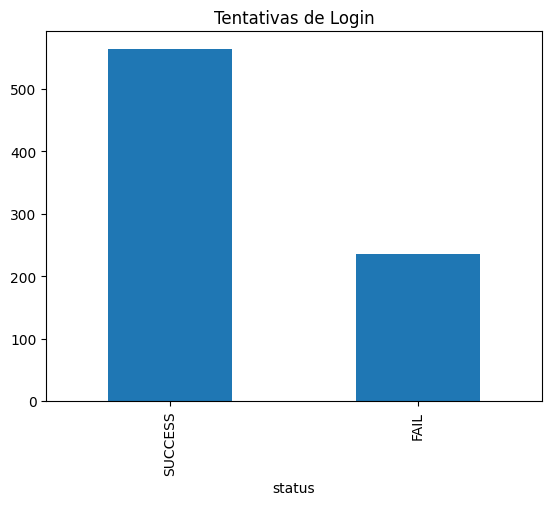

In [48]:
df["status"].value_counts().plot(kind="bar")
plt.title("Tentativas de Login")
plt.show()

## Tipos de ataque

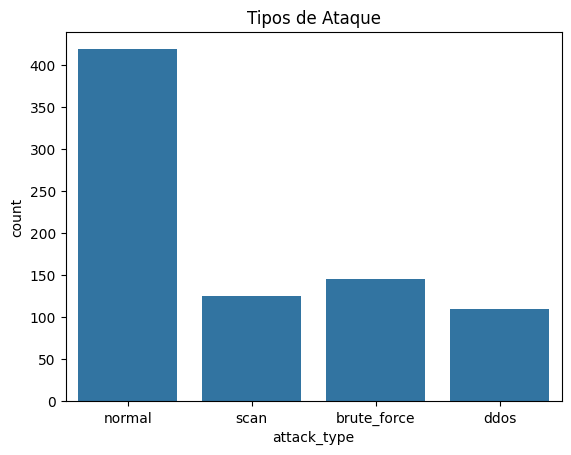

In [49]:
sns.countplot(data=df, x="attack_type")
plt.title("Tipos de Ataque")
plt.show()

## Ataques por horário

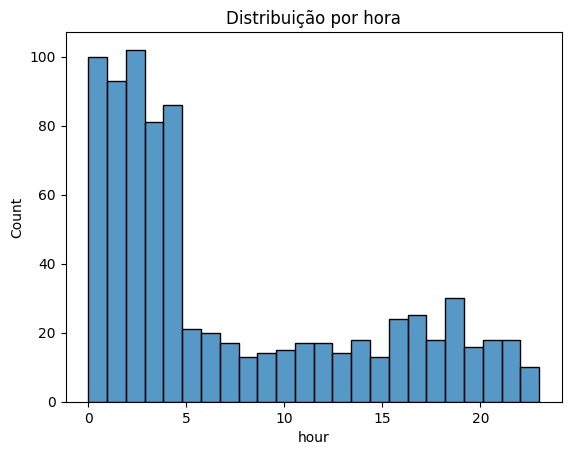

In [50]:
sns.histplot(df["hour"], bins=24)
plt.title("Distribuição por hora")
plt.show()

## Países com mais falhas

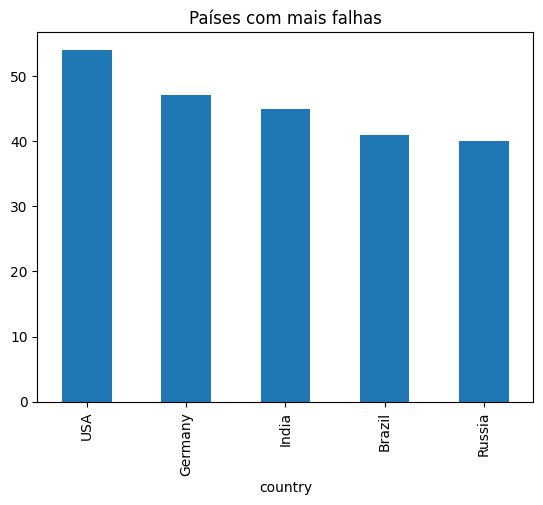

In [51]:
df[df["is_fail"] == 1]["country"].value_counts().head(10).plot(kind="bar")
plt.title("Países com mais falhas")
plt.show()

# Avaliação de tentativas de login


## IPs com mais falhas

In [52]:
fails_por_ip = df.groupby("ip")["is_fail"].sum().sort_values(ascending=False)
fails_por_ip.head(10)

,is_fail
ip,
192.168.1.45,17
192.168.1.25,15
192.168.1.20,13
192.168.1.5,12
192.168.1.15,12
192.168.1.35,10
192.168.1.10,9
192.168.1.55,9
192.168.1.11,6


## Taxa de falha por IP

In [53]:
total_por_ip = df.groupby("ip")["ip"].count()

taxa_falha = (fails_por_ip / total_por_ip).sort_values(ascending=False)
taxa_falha.head(10)

,0
ip,
192.168.1.20,1.000000
192.168.1.45,0.944444
192.168.1.15,0.923077
192.168.1.5,0.800000
192.168.1.25,0.789474
192.168.1.35,0.714286
192.168.1.55,0.692308
192.168.1.10,0.600000
192.168.1.23,0.555556


## Detectar brute force

In [54]:
#IPs com mais de 70% de falhas são considerados suspeitos

suspeitos_brute = taxa_falha[taxa_falha > 0.7]
suspeitos_brute

,0
ip,
192.168.1.20,1.000000
192.168.1.45,0.944444
192.168.1.15,0.923077
192.168.1.5,0.800000
192.168.1.25,0.789474
192.168.1.35,0.714286


## Atividade noturna suspeita

In [55]:
night_activity = df.groupby("ip")["is_night"].sum()
night_activity.sort_values(ascending=False).head(10)

,is_night
ip,
192.168.1.25,19
192.168.1.45,17
192.168.1.10,14
192.168.1.5,13
192.168.1.7,13
192.168.1.20,12
192.168.1.55,12
192.168.1.6,12
192.168.1.15,12


# Machine Learning (Anomaly Detection)

In [56]:
from sklearn.ensemble import IsolationForest

features = df.groupby("ip").agg({
    "is_fail": "sum",
    "user_id": "nunique",
    "attack_type": "count",
    "is_night": "sum"
})

features.columns = ["fails", "unique_users", "total_requests", "night_activity"]

model = IsolationForest(contamination=0.1, random_state=42)
features["anomaly"] = model.fit_predict(features)

suspeitos = features[features["anomaly"] == -1]
suspeitos

,fails,unique_users,total_requests,night_activity,anomaly
ip,,,,,
192.168.1.25,15,16,19,19,-1
192.168.1.28,0,5,6,3,-1
192.168.1.45,17,14,18,17,-1
192.168.1.47,3,17,24,9,-1
192.168.1.53,1,6,7,3,-1
192.168.1.57,3,17,21,11,-1


# Visualização de anomalias

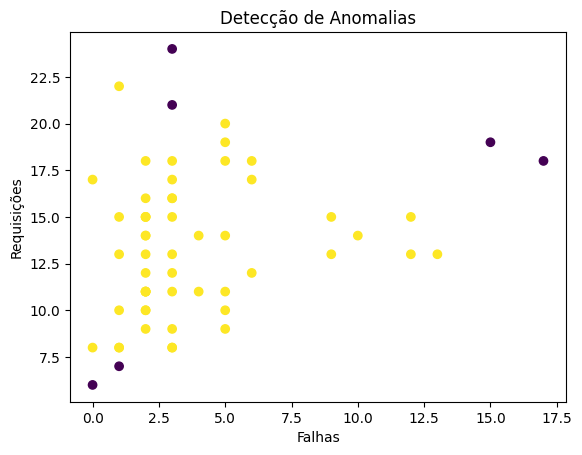

In [57]:
plt.scatter(features["fails"], features["total_requests"], c=features["anomaly"])
plt.xlabel("Falhas")
plt.ylabel("Requisições")
plt.title("Detecção de Anomalias")
plt.show()